In [1]:
from plots import plot_final_policies, plot_final_policies_linear, plot_specific_state_policy, plot_specific_state_policy_linear
# new
from plots import plot_policy_convergence, plot_expected_value_convergence, plot_policy, plot_transition_matrix,plot_karma_level_distribution

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import copy
from pathlib import Path
import pickle
import os

In [3]:
os.getcwd()

'/Users/mathis/Documents/EPFL/Master_Thesis/CARMA-Congestion_Railway/0-Simulation'

In [4]:
path = "../results_1/"

with open(path + 'groups.pkl', 'rb') as f:
    groups = pickle.load(f)

with open(path + 'error_vec.pkl', 'rb') as f:
    error_vec = pickle.load(f)

with open(path + 'expected_value_vec.pkl', 'rb') as f:
    expected_value_vec = pickle.load(f)

with open(path + 'simulation_params.pkl', 'rb') as f:
    n_day, n_groups, K, n_travelers = pickle.load(f)

with open(path + 'system.pkl', 'rb') as f:
    system = pickle.load(f)

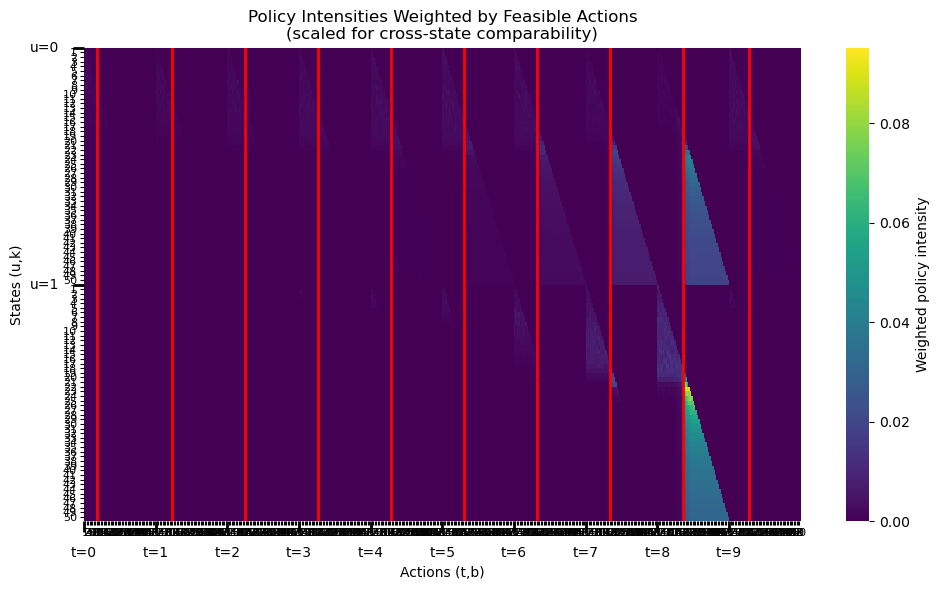

In [5]:
plot_policy(groups[0], b_star=system.b_star)

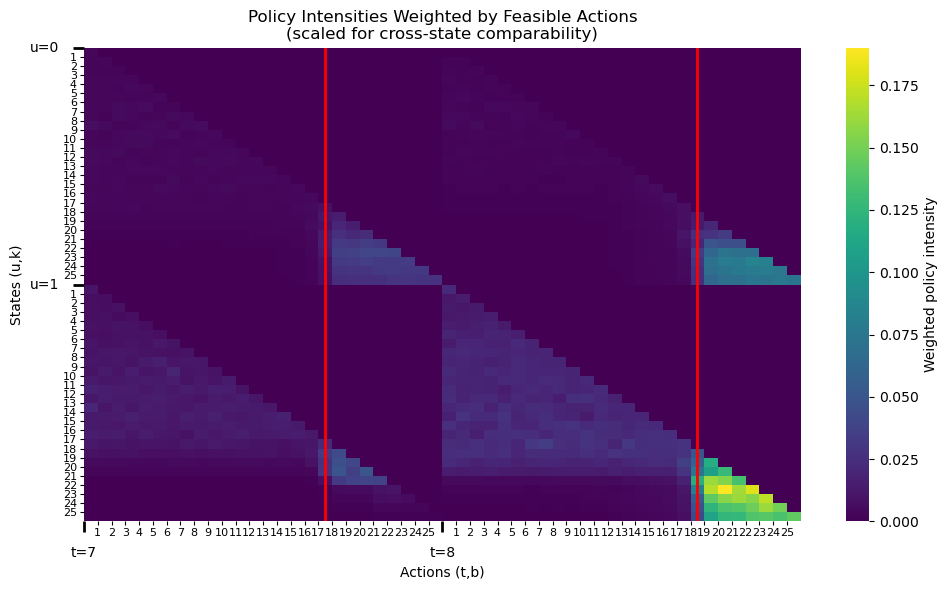

In [17]:
group = groups[0]

# plot_policy(group, b_star=system.b_star)  # full matrix
max_karma_level = 25 # for plotting
k_list = list(range(max_karma_level + 1))
b_list = k_list
plot_policy(group, u=[0,1], k=k_list, t=[7,8], b=b_list, b_star=system.b_star)


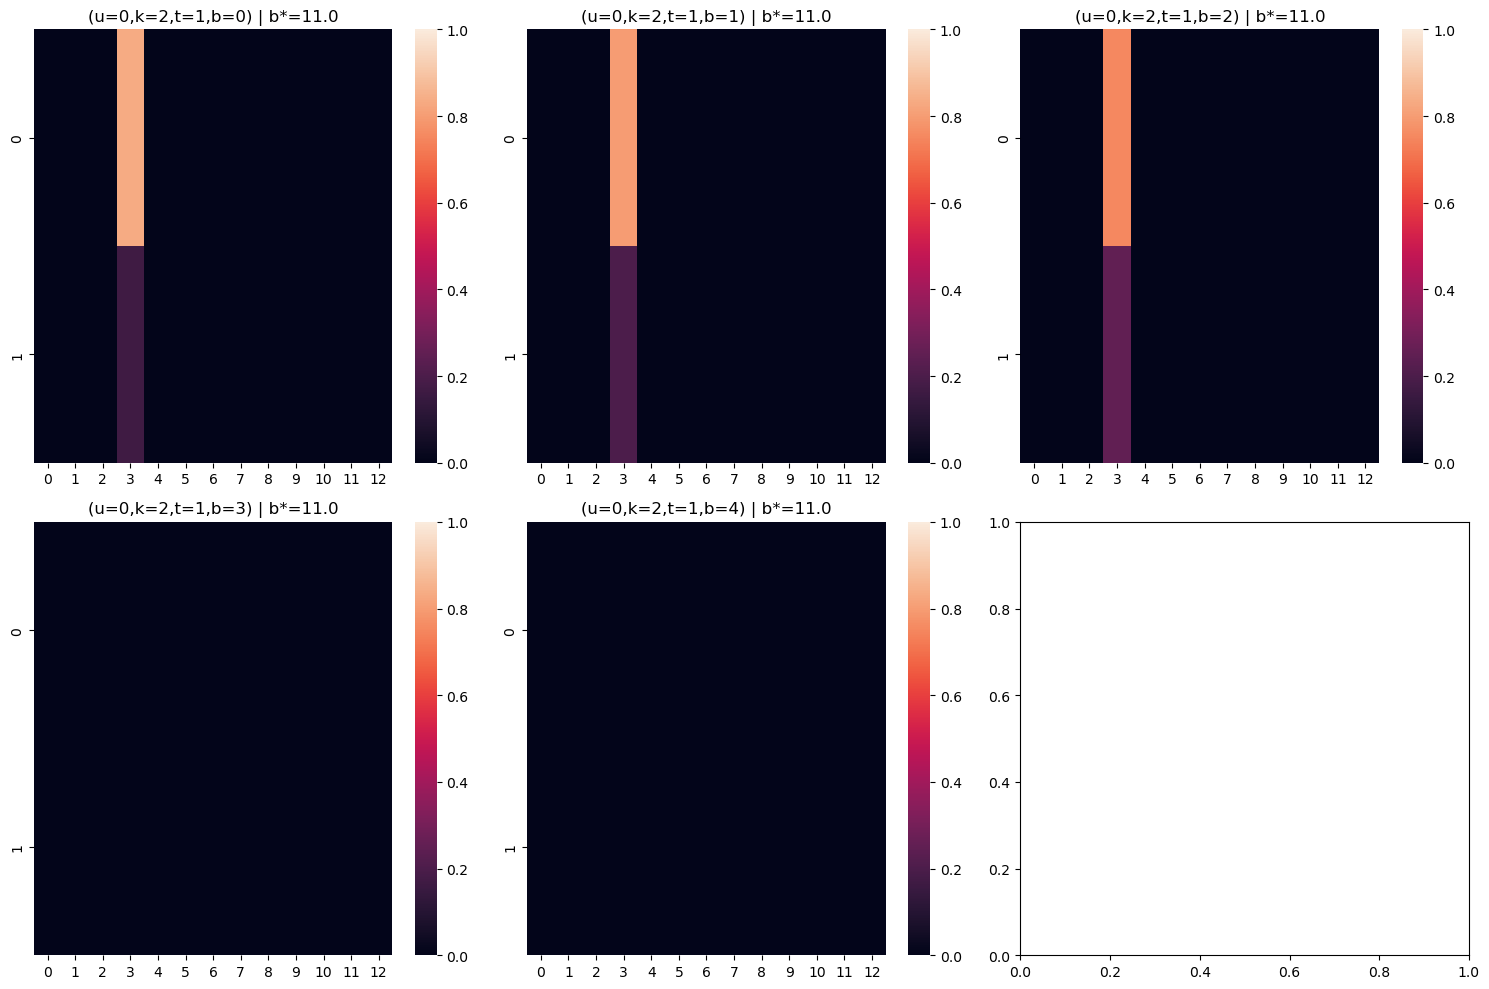

In [7]:
plot_transition_matrix(group, u=0, k=[2], t=1, b=[0,1,2,3,4], b_star=system.b_star, window_size=10)


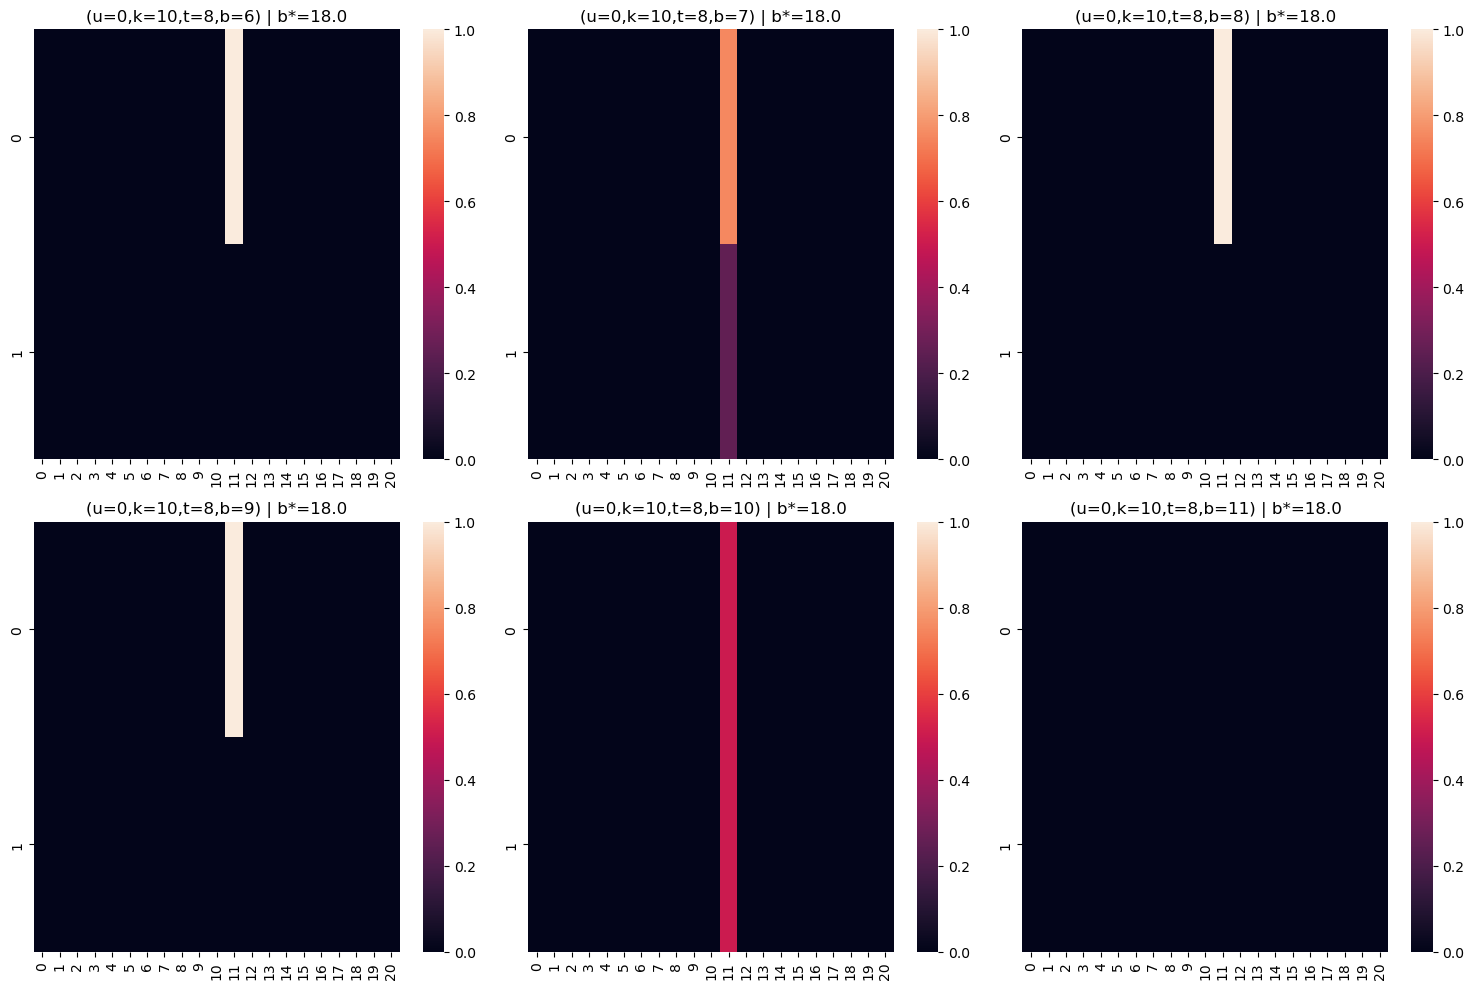

In [8]:
plot_transition_matrix(group, u=0, k=[10], t=8, b=[6,7,8,9,10,11], b_star=system.b_star, window_size=10)

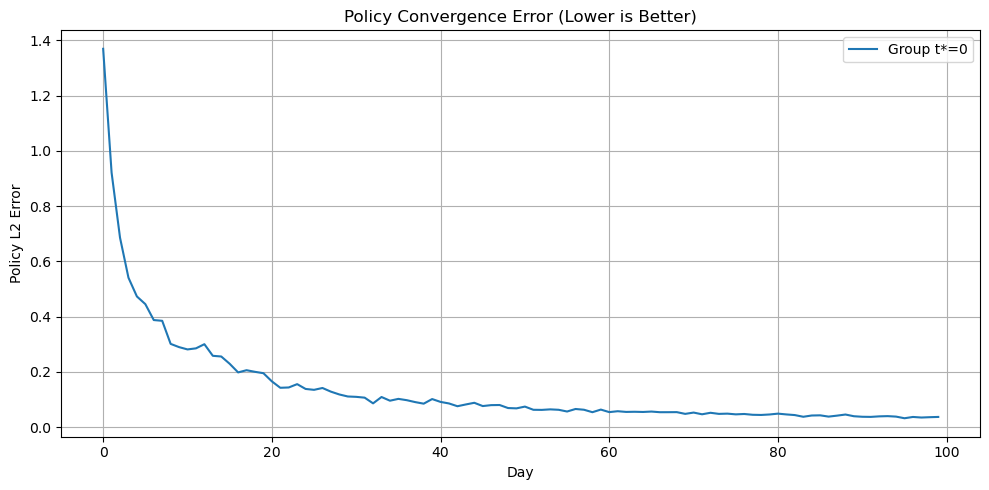

In [9]:
plot_policy_convergence(error_vec, n_day, n_groups)

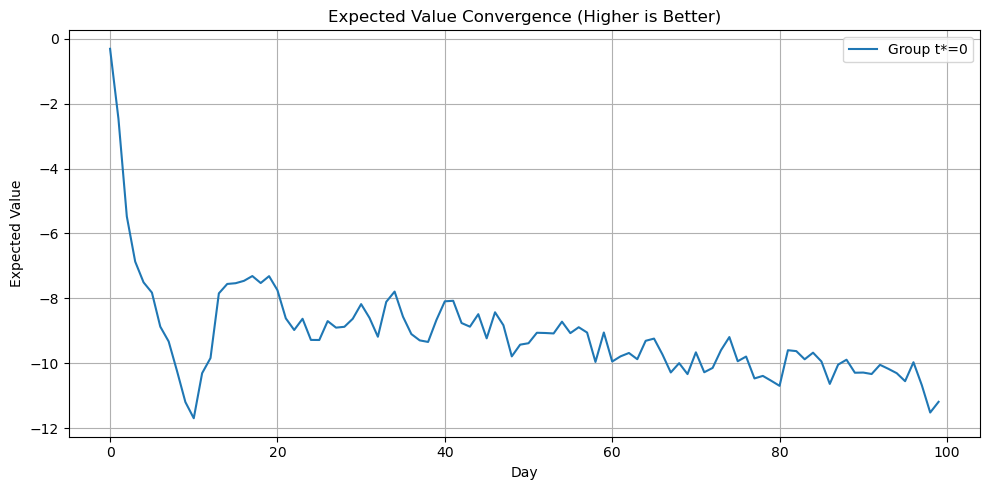

In [10]:
plot_expected_value_convergence(expected_value_vec, n_day, n_groups)

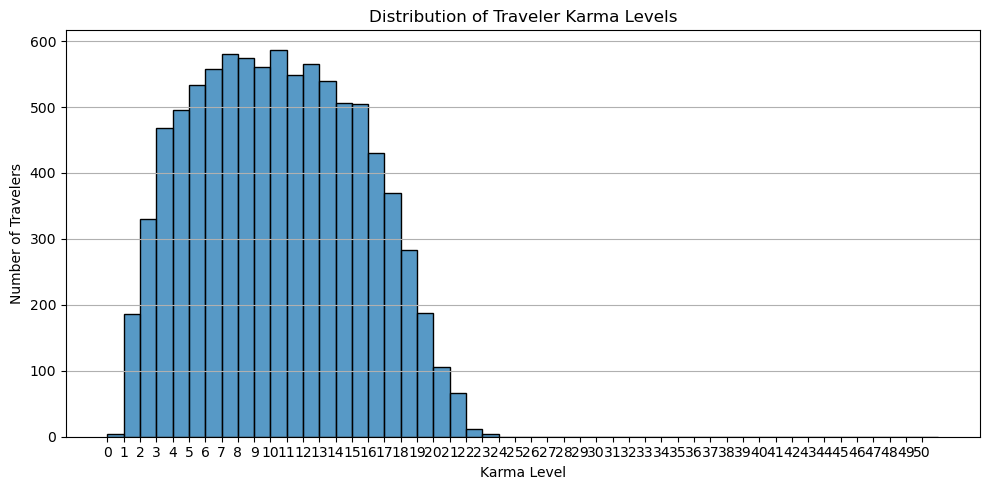

In [11]:
plot_karma_level_distribution(group.travelers, group.K)

In [13]:
Q_reshaped = group.Q.reshape(group.pi.shape)

# state index
for u in range(group.U):
    for k in range(group.K + 1):
        state_index = u * (group.K + 1) + k
        # action_index
        for t in range(group.T):
            for b in range(group.K+1):
                action_index = t * (group.K + 1) + b

                # select a specific state and action to print
                if u == 0 and k ==1 and (b ==0 or b == 1):
                    print(f"State (u={u}, k={k}), Action (t={t}, b={b}): Q-value = {Q_reshaped[state_index, action_index]}, Policy action = {group.pi[state_index, action_index]}, New Policy action = {group.perturbed_best_response_dynamic()[state_index, action_index]}")

State (u=0, k=1), Action (t=0, b=0): Q-value = -39.861834409297046, Policy action = 0.0203485656529665, New Policy action = 0.005313788075000048
State (u=0, k=1), Action (t=0, b=1): Q-value = -39.050104816721515, Policy action = 0.034513138234615326, New Policy action = 0.011965584009885788
State (u=0, k=1), Action (t=1, b=0): Q-value = -39.08006460711509, Policy action = 0.0382964089512825, New Policy action = 0.011612414382398129
State (u=0, k=1), Action (t=1, b=1): Q-value = -39.08006460711509, Policy action = 0.0339403972029686, New Policy action = 0.011612414382398129
State (u=0, k=1), Action (t=2, b=0): Q-value = -38.051282129804974, Policy action = 0.04373566433787346, New Policy action = 0.03248756006360054
State (u=0, k=1), Action (t=2, b=1): Q-value = -37.982397116647945, Policy action = 0.04578806832432747, New Policy action = 0.034804344177246094
State (u=0, k=1), Action (t=3, b=0): Q-value = -37.63326578629341, Policy action = 0.0477818101644516, New Policy action = 0.0493